<a href="https://colab.research.google.com/github/PuskarDas/Financial_News_Sentiments-vs-NIFTY50/blob/main/Financial_News_Sentiment_vs_NIFTY50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial News Sentiment vs. NIFTY50 Analysis
### Data Science Bootcamp Homework Project

**Part A** rebuilds the official reference project: a rule-based sentiment analysis of financial news, compared against NIFTY50 movement.

**Part B** scales it into a full ML pipeline: proper feature engineering, time-aware train/test splits, multiple models, hyperparameter tuning, and honest evaluation.

**Before running:** upload `news.csv` and `nifty50.csv` (from the `data/` folder of the [GitHub repo](https://github.com/eklavyakiit/Financial-News-Sentiment-vs-NIFTY50-Analysis)) into your Colab session (folder icon on the left → upload), or mount Google Drive and adjust the paths below.


---
## Part A — The Reference Project (Rule-Based Approach)

### Cell 1 — Import Pandas

In [6]:
import pandas as pd

### Loading the News Dataset

### Cell 2 — Load news.csv

In [7]:
news = pd.read_csv("news.csv", encoding='latin1')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


`encoding='latin1'` matters here. Scraped news datasets often contain characters (curly quotes, rupee symbols, accented names) that break the default UTF-8 reader.

### Cell 3 — Inspect Columns

In [8]:
print(news.columns)

Index(['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'],
      dtype='object', length=189)


The raw file carries far more columns than needed. Drop them explicitly rather than guessing which ones matter.

### Cell 4 — Drop Unneeded Columns

In [9]:
cols_to_drop = ['Description', 'Author', 'Content', 'Keywords'] + \
    [c for c in news.columns if c.startswith('Unnamed')]
news = news.drop(columns=cols_to_drop)
print(news.columns.tolist())

['Title', 'Date']


### Cell 5 — Keep Only Date & Title

⚠️ This assumes the first two columns are Title and Date after the drop above (verify with the print above before running on different data).

In [10]:
news = news.iloc[:, :2]
print(news.columns.tolist())

['Title', 'Date']


### Cleaning the News Data

### Cell 6/7 — Check for Missing Values

In [11]:
print(news.columns)
print(news.isnull().sum())

Index(['Title', 'Date'], dtype='object')
Title    0
Date     0
dtype: int64


### Cell 8–10 — Drop Nulls, Duplicates, and Strip Whitespace

In [12]:
news = news.dropna()
news = news.drop_duplicates()
news['Title'] = news['Title'].str.strip()

### Cell 11 — Sanity Check

In [13]:
print(news.info())
print(news.describe())
print(news.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3348 entries, 0 to 3348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3348 non-null   object
 1   Date    3348 non-null   object
dtypes: object(2)
memory usage: 78.5+ KB
None
                                                    Title        Date
count                                                3348        3348
unique                                               3306         174
top     Buy Adani Ports and SEZ; target of Rs 1700: Mo...  29-07-2025
freq                                                    3          75
                                               Title        Date
0  Aurobindo Pharma, Dr Reddy's, Lupin, other pha...  08-07-2025
1  Bharti Airtel share price falls 1.53%; stock a...  18-07-2025
2  Indian Oil and Adani Gas JV plans $161 million...  09-07-2025
3  Cipla Shares Fall in Today's Trading Session A...  03-06-2025
4  Here are the sectors and stocks

### Grouping News by Date

There are multiple headlines per day, so group them into one row per date before merging with the stock data.

### Cell 12 — Group Headlines by Date

In [14]:
grouped_news = (news.groupby("Date")["Title"].apply(list).reset_index())
print(grouped_news.head())
print(grouped_news.shape)

                                                Date  \
0   just some time back that you resisted going t...   
1                                         01-04-2025   
2                                         01-05-2025   
3                                         01-06-2025   
4                                         01-07-2025   

                                               Title  
0    [ur. You're always in a t-shirt. Like you said]  
1  [Indian companies gear up for nuclear expansio...  
2  [Adani Enterprises Q4 Results: Net profit rise...  
3  [Trade Spotlight: How should you trade CDSL, M...  
4  [PSU bank stocks snap 5-day gaining streak ami...  
(174, 2)


### Cell 16 — Drop the First Row

⚠️ This drops whatever ended up first after grouping — in this dataset that's a malformed/placeholder date left over from the raw export. Check `grouped_news.head()` above and confirm row 0 really is junk before running this.

In [15]:
grouped_news = grouped_news.iloc[1:]
print(grouped_news.shape)

(173, 2)


### Cell 18 — Standardize the Grouped Date Column

In [16]:
grouped_news['Date'] = pd.to_datetime(
    grouped_news['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)
print(grouped_news['Date'].isnull().sum(), 'unparseable dates')

0 unparseable dates


### Cell 19 — Save a Checkpoint

Good practice on any multi-stage pipeline — if a later step goes wrong, you can restart from here.

In [17]:
grouped_news.to_csv("grouped_news.csv", index=False)

### Loading and Cleaning the NIFTY50 Data

### Cell 21 — Load nifty50.csv

In [18]:
stock = pd.read_csv("nifty50.csv", encoding='cp1252')
print(stock.columns.tolist())

['ï»¿Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ', 'Turnover (â‚¹ Cr)']


### Cell 23 — Rename Columns

In [19]:
stock.columns = [
    'date',
    'open',
    'high',
    'low',
    'close',
    'shares_traded',
    'turnover_cr'
]

### Cell 25/26 — Fix Types

News dates used an explicit format string; stock dates use `dayfirst=True` instead. Both are valid — the key is standardizing both sides to real pandas datetimes before merging.

In [20]:
stock['shares_traded'] = stock['shares_traded'].astype(float)
stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')
print(stock.head())

        date      open      high       low     close  shares_traded  \
0 2025-08-29  24466.70  24572.45  24404.70  24426.85    325543583.0   
1 2025-08-28  24695.80  24702.65  24481.60  24500.90    326601486.0   
2 2025-08-26  24899.50  24919.65  24689.60  24712.05    750473927.0   
3 2025-08-25  24949.15  25021.55  24894.35  24967.75    213032133.0   
4 2025-08-22  25064.15  25084.85  24859.15  24870.10    210165384.0   

   turnover_cr  
0     26796.69  
1     29371.67  
2     47068.20  
3     19871.25  
4     19655.78  


/tmp/ipykernel_1123/2136886351.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')


### Merging the Two Datasets

### Cell 28 — Inner Merge on Date

In [21]:
merged = pd.merge(stock, grouped_news, left_on='date', right_on='Date', how='inner')
print(merged.shape)

(132, 9)


### Cell 29 — Confirm No Nulls Slipped Through

In [22]:
print(merged.isnull().sum())

date             0
open             0
high             0
low              0
close            0
shares_traded    0
turnover_cr      0
Date             0
Title            0
dtype: int64


### Feature Engineering — Market Movement & Target

### Cell 32/33 — Movement and Binary Target

`target = 1` means the market closed higher than it opened that same day. This same-day framing matters a lot when evaluating the prediction later — and even more in Part B.

In [23]:
merged['movement'] = merged['close'] - merged['open']

def check_movement(x):
    if x > 0:
        return 1
    else:
        return 0

merged['target'] = merged['movement'].apply(check_movement)
print(merged['target'].value_counts())

target
0    67
1    65
Name: count, dtype: int64


### Rule-Based Sentiment Analysis

Two hand-curated financial word lists (200+ terms each), no NLP libraries.

### Cell 35 — Positive & Negative Word Lists

In [24]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing', 'grows',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'bullish', 'bull', 'bull run', 'bulls',
    'record', 'record-high', 'record high', 'all-time high', 'peak', 'peaked',
    'upgrade', 'upgraded', 'upgrades', 'upgrading',
    'buyback', 'share buyback', 'repurchase',
    'guidance raised', 'guidance upgrade', 'raised guidance',
    'loan growth', 'credit growth', 'deposit growth',
    'oversubscribed', 'oversubscription',
    'multibagger', 'broad-based rally',
    'strong', 'stronger', 'strongest', 'strength',
    'boost', 'boosted', 'boosting', 'boosts',
    'jump', 'jumps', 'jumped', 'jumping',
    'soar', 'soars', 'soared', 'soaring',
    'climb', 'climbs', 'climbed', 'climbing',
    'advance', 'advances', 'advanced', 'advancing',
    'beat', 'beats', 'beating', 'outperform', 'outperformed', 'outperforms', 'outperformance',
    'exceed', 'exceeds', 'exceeded', 'exceeding', 'exceeded expectations',
    'positive', 'positively', 'optimism', 'optimistic',
    'recovery', 'recovers', 'recovered', 'recovering', 'rebound', 'rebounds', 'rebounded', 'rebounding',
    'expansion', 'expand', 'expands', 'expanded', 'expanding',
    'invest', 'investment', 'investments', 'investing', 'inflow', 'inflows',
    'fii buying', 'dii buying', 'institutional buying', 'foreign inflows',
    'dividend', 'dividends', 'special dividend', 'interim dividend',
    'bonus', 'bonus issue', 'stock split',
    'ipo', 'listing gains', 'strong debut', 'stellar debut',
    'merger', 'acquisition', 'stake buy', 'stake acquisition',
    'partnership', 'collaboration', 'tie-up', 'joint venture',
    'order win', 'order book', 'new orders', 'bags order', 'wins contract', 'wins deal',
    'expansion plan', 'capacity expansion', 'new plant',
    'rate cut', 'repo rate cut', 'dovish', 'easing',
    'stimulus', 'fiscal support', 'relief package', 'incentive',
    'reforms', 'policy support', 'tax cut', 'subsidy',
    'demand', 'strong demand', 'robust demand', 'healthy demand',
    'margin expansion', 'improved margins', 'higher margins',
    'top gainer', 'top performer', 'best performer', 'blue chip rally',
    'green', 'in the green', 'closes higher', 'ends higher', 'settles higher',
    'buy rating', 'buy call', 'accumulate', 'overweight',
    'target raised', 'target price hike', 'price target raised',
    'net profit rises', 'revenue growth', 'sales growth', 'earnings beat',
    'q4 results beat', 'q1 results beat', 'strong quarter', 'record revenue',
    'FII inflow', 'DII inflow', 'net buyers', 'net inflow',
    'export growth', 'GDP growth', 'economic growth', 'manufacturing growth',
    'confidence', 'consumer confidence', 'business confidence',
    'all-time high close', 'lifetime high', 'fresh high', '52-week high',
    'debt reduction', 'deleveraging', 'improved balance sheet',
    'credit rating upgrade', 'rating upgrade', 'outlook upgraded to positive',
    'strong guidance', 'raised outlook', 'positive outlook',
    'value creation', 'wealth creation', 'shareholder value',
    'momentum', 'positive momentum', 'bullish momentum',
    'circuit', 'upper circuit',
    'settles in green', 'ends in green', 'closes in green',
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing', 'loss-making',
    'decline', 'declines', 'declined', 'declining',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'nosedive', 'collapse', 'collapses', 'collapsed', 'collapsing',
    'bearish', 'bear market', 'bears',
    'downgrade', 'downgraded', 'downgrades', 'downgrading',
    'recession', 'stagflation', 'slowdown', 'slows', 'slowing',
    'layoffs', 'retrenchment', 'downsizing', 'job cuts', 'workforce reduction',
    'default', 'bankruptcy', 'insolvency', 'insolvent',
    'npa', 'bad loan', 'bad loans', 'write-off', 'writeoff',
    'rate hike', 'hawkish', 'monetary tightening', 'tightening',
    'fii selling', 'dii selling', 'institutional selling', 'foreign outflows',
    'circuit breaker', 'lower circuit',
    'fall', 'falls', 'fell', 'falling', 'falter', 'faltered', 'faltering',
    'drop', 'drops', 'dropped', 'dropping',
    'slump', 'slumps', 'slumped', 'slumping',
    'tumble', 'tumbles', 'tumbled', 'tumbling',
    'sink', 'sinks', 'sank', 'sinking',
    'slide', 'slides', 'slid', 'sliding',
    'weak', 'weaker', 'weakest', 'weakness',
    'miss', 'misses', 'missed', 'missing', 'underperform', 'underperformed', 'underperforms', 'underperformance',
    'below expectations', 'disappointing', 'disappoints', 'disappointed',
    'negative', 'negatively', 'pessimism', 'pessimistic',
    'contraction', 'contract', 'contracts', 'contracted', 'contracting',
    'outflow', 'outflows', 'divest', 'divestment', 'sell-off', 'selloff',
    'debt', 'high debt', 'debt burden', 'debt trap', 'rising debt',
    'fraud', 'scam', 'scandal', 'probe', 'investigation', 'raid',
    'lawsuit', 'litigation', 'penalty', 'penalties', 'fine', 'fined',
    'strike', 'protest', 'unrest', 'shutdown', 'halt', 'halted', 'suspended',
    'volatility', 'volatile', 'turmoil', 'uncertainty', 'uncertain',
    'inflation', 'rising inflation', 'high inflation', 'cost pressure', 'input cost pressure',
    'demand slowdown', 'weak demand', 'sluggish demand', 'muted demand',
    'margin pressure', 'margin contraction', 'lower margins', 'squeezed margins',
    'top loser', 'worst performer', 'laggard', 'laggards',
    'red', 'in the red', 'closes lower', 'ends lower', 'settles lower',
    'sell rating', 'sell call', 'reduce', 'underweight',
    'target cut', 'target price cut', 'price target lowered',
    'net profit falls', 'net loss', 'revenue decline', 'sales decline', 'earnings miss',
    'q4 results miss', 'q1 results miss', 'weak quarter', 'profit warning',
    'FII outflow', 'DII outflow', 'net sellers', 'net outflow',
    'export decline', 'GDP slowdown', 'economic slowdown', 'manufacturing contraction',
    'crisis', 'financial crisis', 'liquidity crisis', 'cash crunch',
    'downturn', 'correction', 'market correction', 'sharp correction',
    'geopolitical tension', 'war', 'conflict', 'sanctions', 'tariffs', 'trade war',
    '52-week low', 'fresh low', 'lifetime low', 'multi-year low',
    'rising debt burden', 'leveraged', 'over-leveraged',
    'credit rating downgrade', 'rating downgrade', 'outlook downgraded to negative',
    'weak guidance', 'lowered outlook', 'negative outlook', 'cautious outlook',
    'value erosion', 'wealth erosion', 'shareholder losses',
    'panic', 'panic selling', 'bearish momentum',
    'resignation', 'resigns', 'quits', 'steps down', 'ceo exit',
    'delay', 'delays', 'delayed', 'postponed', 'deferred',
    'cyberattack', 'data breach', 'hack', 'hacked',
    'settles in red', 'ends in red', 'closes in red',
]



### Cell 36/37 — Scoring Function

⚠️ `merged['Title']` holds a Python list of headlines, not a single string. `str(text)` stringifies the whole list (brackets and all) before scoring — this still works since `.count()` just searches substrings, but it's worth knowing why. Try `' '.join(text)` as a stretch improvement and see if scores change.

This is an **unbounded** score (raw count difference), not normalized — a day with many headlines will tend toward larger-magnitude scores purely from volume.

In [25]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

merged['sentiment_score'] = merged['Title'].apply(sentiment_score)
print(merged[['date','sentiment_score']].head())

        date  sentiment_score
0 2025-08-21                4
1 2025-08-20                7
2 2025-08-19                8
3 2025-08-18               23
4 2025-08-14                7


### Exploratory Data Analysis

### Cell 39–41 — Inspect the Scores

In [26]:
print(merged.head())
print(merged.describe())
print(merged['sentiment_score'].value_counts())
print(merged.groupby('target')['sentiment_score'].mean())

        date      open      high       low     close  shares_traded  \
0 2025-08-21  25142.00  25153.65  25054.90  25083.75    226542052.0   
1 2025-08-20  24965.80  25088.70  24929.70  25050.55    287054119.0   
2 2025-08-19  24891.35  25012.65  24873.95  24980.65    252340828.0   
3 2025-08-18  24938.20  25022.00  24852.85  24876.95    363071305.0   
4 2025-08-14  24607.25  24673.65  24596.90  24631.30    270162203.0   

   turnover_cr       Date                                              Title  \
0     21865.07 2025-08-21  [Stocks to Watch Today: Clean Science, Shanti ...   
1     25330.45 2025-08-20  [KPR Mill shares rise 2.09% in Wednesday's ses...   
2     24781.97 2025-08-19  [Kalyan Jewellers India shares decline 2.45% a...   
3     37637.67 2025-08-18  [BSE, HDFC AMC, MCX, other capital market stoc...   
4     22375.44 2025-08-14  [Lux Industries Standalone June 2025 Net Sales...   

   movement  target  sentiment_score  
0    -58.25       0                4  
1     84.75   

### Cell 42–43 — Histogram

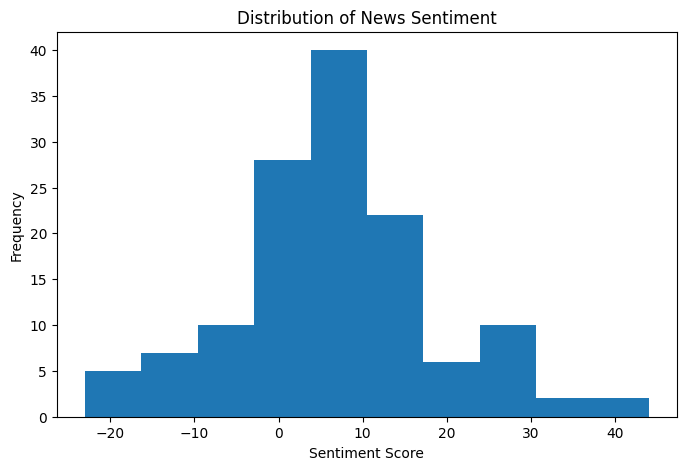

In [27]:
import os
os.makedirs("plots", exist_ok=True)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(merged['sentiment_score'])
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")
plt.savefig("plots/histogram.png", dpi=300, bbox_inches='tight')
plt.show()

### Cell 44 — Bar Plot: Average Sentiment by Direction

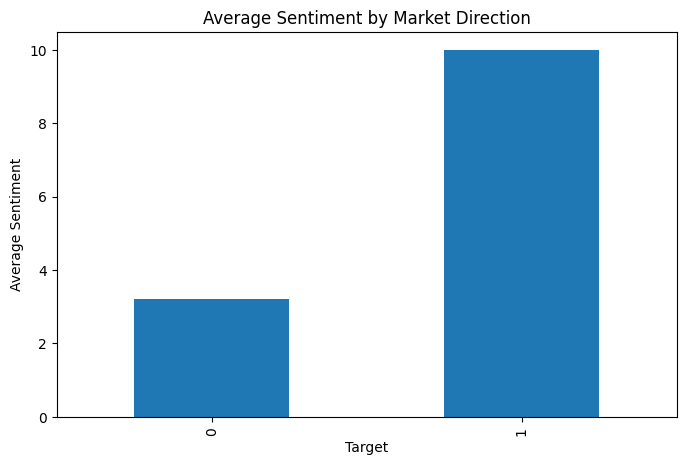

In [28]:
plt.figure(figsize=(8,5))
merged.groupby('target')['sentiment_score'].mean().plot(kind='bar')
plt.xlabel("Target")
plt.ylabel("Average Sentiment")
plt.title("Average Sentiment by Market Direction")
plt.savefig("plots/barplot.png", dpi=300, bbox_inches='tight')
plt.show()

### Cell 45 — Scatter Plot: Sentiment vs Movement

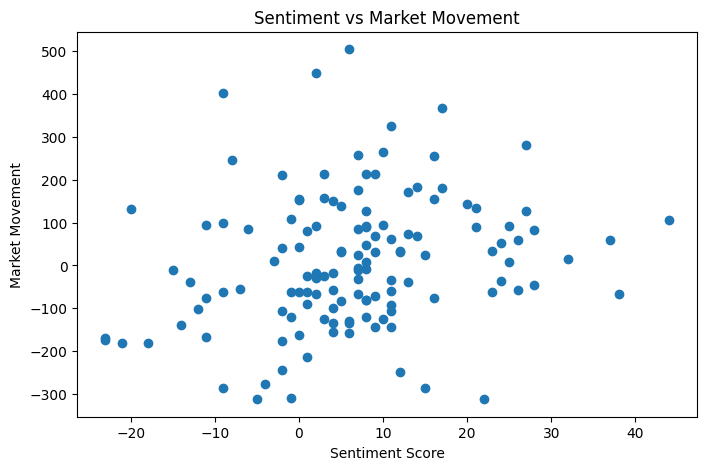

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(merged['sentiment_score'], merged['movement'])
plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")
plt.title("Sentiment vs Market Movement")
plt.savefig("plots/scatterplot.png", dpi=300, bbox_inches='tight')
plt.show()

### Prediction Logic

### Cell 46/47 — Three-Way Prediction Label

In [30]:
def predict_market(score):
    if score > 0:
        return "UP"
    elif score < 0:
        return "DOWN"
    else:
        return "NEUTRAL"

merged['prediction'] = merged['sentiment_score'].apply(predict_market)
print(merged[['date', 'sentiment_score', 'prediction']].head())

        date  sentiment_score prediction
0 2025-08-21                4         UP
1 2025-08-20                7         UP
2 2025-08-19                8         UP
3 2025-08-18               23         UP
4 2025-08-14                7         UP


### Cell 48/49 — Binary Prediction to Match the Target

In [31]:
def binary_prediction(score):
    if score > 0:
        return 1
    return 0

merged['prediction_binary'] = merged['sentiment_score'].apply(binary_prediction)

### Performance Evaluation

### Cell 50 — Accuracy

⚠️ Read this number carefully. `sentiment_score` and `target` are both computed from the **same trading day** — a high accuracy here reflects same-day co-movement (major news and price moves often share the same underlying cause), **not** predictive power. It could not be traded on directly, since you'd need tomorrow's headlines before today's close.

Also compute a majority-class baseline for comparison — this isn't in the reference notebook, but it's the single easiest addition that makes the evaluation section stronger.

In [32]:
accuracy = (merged['prediction_binary'] == merged['target']).mean()
print()
print("Prediction Accuracy:")
print(round(accuracy*100, 2), "%")

baseline_accuracy = (merged['target'] == merged['target'].mode()[0]).mean()
print()
print("Majority-Class Baseline:")
print(round(baseline_accuracy*100, 2), "%")


Prediction Accuracy:
56.82 %

Majority-Class Baseline:
50.76 %


### Cell 51 — Save the Final Dataset

In [33]:
merged = merged.sort_values('date').reset_index(drop=True)
merged.to_csv("final_project_dataset.csv", index=False)
print("Final dataset saved successfully.")

Final dataset saved successfully.


### Part A — Checkpoint

At this point you've reproduced the entire reference pipeline: cleaned two messy real-world datasets, merged them correctly on date, built your own financial sentiment scorer from scratch, visualized the relationship three different ways, and evaluated a simple same-day prediction rule honestly, including its limitations. This alone is a legitimate portfolio project.

Everything from here is the stretch goal that turns it into something genuinely resume-grade.

---
## Part B — Scaling Up to a Full Machine Learning Pipeline

Part A proved the concept with hand-written rules and a same-day co-movement check. Part B replaces the fixed rule with a learned model **and** fixes the same-day framing so the model predicts something that hasn't happened yet — tomorrow's direction, not today's.

### 1. Fixing the Prediction Target: Predict Tomorrow, Not Today

### Cell B1 — Load and Shift the Target

In [34]:
import pandas as pd
import numpy as np

ml_df = pd.read_csv('final_project_dataset.csv', parse_dates=['date'])
ml_df = ml_df.sort_values('date').reset_index(drop=True)
ml_df['next_day_target'] = ml_df['target'].shift(-1)
ml_df = ml_df.dropna(subset=['next_day_target'])
ml_df['next_day_target'] = ml_df['next_day_target'].astype(int)
print(ml_df.shape)

(131, 15)


`next_day_target` is now the thing worth predicting: does tomorrow close up or down, given everything we know as of today's close? This single change is what separates a co-movement observation from an actual forecasting attempt.

### 2. Feature Engineering for ML

### Cell B2 — Expanded Feature Set

In [35]:
# Rolling sentiment features
ml_df['sentiment_ma3'] = ml_df['sentiment_score'].rolling(3).mean()
ml_df['sentiment_ma7'] = ml_df['sentiment_score'].rolling(7).mean()
ml_df['sentiment_std3'] = ml_df['sentiment_score'].rolling(3).std()

# Lagged price action (avoids leaking same-day info about the target)
ml_df['movement_lag1'] = ml_df['movement'].shift(1)
ml_df['movement_lag2'] = ml_df['movement'].shift(2)

# Volume and volatility proxies
ml_df['volume_change'] = ml_df['shares_traded'].pct_change()
ml_df['high_low_spread'] = (ml_df['high'] - ml_df['low']) / ml_df['open'] * 100

ml_df = ml_df.dropna().reset_index(drop=True)
print(ml_df.shape)

(125, 22)


### 3. Time-Aware Train/Test Split

Financial time series must never be split randomly — that leaks future information into training. Split chronologically instead.

### Cell B3 — Chronological Split

In [36]:
feature_cols = ['sentiment_score', 'sentiment_ma3', 'sentiment_ma7', 'sentiment_std3',
                'movement_lag1', 'movement_lag2', 'volume_change', 'high_low_spread']

X = ml_df[feature_cols]
y = ml_df['next_day_target']

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape[0]} days | Test: {X_test.shape[0]} days')

Train: 100 days | Test: 25 days


⚠️ Never use `train_test_split(..., shuffle=True)` on this data — a shuffled split lets the model 'see' days adjacent to the test set during training, inflating accuracy in a way that won't hold up out of sample.

### 4. Model Selection & Training

### Cell B4 — Baseline Numbers to Beat

In [37]:
majority_baseline = (y_test == y_test.mode()[0]).mean()
print('Majority-class baseline (test period):', round(majority_baseline*100, 2), '%')

Majority-class baseline (test period): 56.0 %


### Cell B5 — Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression accuracy: 0.56
              precision    recall  f1-score   support

           0       0.80      0.29      0.42        14
           1       0.50      0.91      0.65        11

    accuracy                           0.56        25
   macro avg       0.65      0.60      0.53        25
weighted avg       0.67      0.56      0.52        25



### Cell B6 — Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.48
              precision    recall  f1-score   support

           0       0.56      0.36      0.43        14
           1       0.44      0.64      0.52        11

    accuracy                           0.48        25
   macro avg       0.50      0.50      0.48        25
weighted avg       0.50      0.48      0.47        25



### Cell B7 — Gradient Boosting (XGBoost)

In [40]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost accuracy: 0.52
              precision    recall  f1-score   support

           0       0.60      0.43      0.50        14
           1       0.47      0.64      0.54        11

    accuracy                           0.52        25
   macro avg       0.53      0.53      0.52        25
weighted avg       0.54      0.52      0.52        25



With roughly six months of trading days, don't be surprised if simpler models (logistic regression, shallow random forest) match or beat XGBoost. Small financial datasets punish overly complex models — an expected and worthwhile finding to report, not a failure.

### 5. Hyperparameter Tuning

### Cell B8 — TimeSeriesSplit + GridSearchCV

In [41]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)

best_rf = grid_search.best_estimator_
print('Tuned test accuracy:', accuracy_score(y_test, best_rf.predict(X_test)))

Best params: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV accuracy: 0.5625
Tuned test accuracy: 0.44


### 6. Evaluation & Backtesting

Accuracy alone isn't enough for a market-prediction model. Simulate a naive trading strategy driven by the model's predictions and compare it to simply holding NIFTY50 over the same period.

### Cell B9 — Confusion Matrix Heatmap

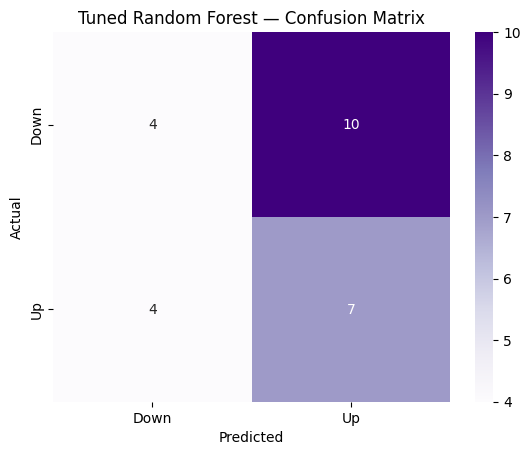

In [42]:
import seaborn as sns

cm = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.show()

### Cell B10 — Simple Backtest vs. Buy-and-Hold

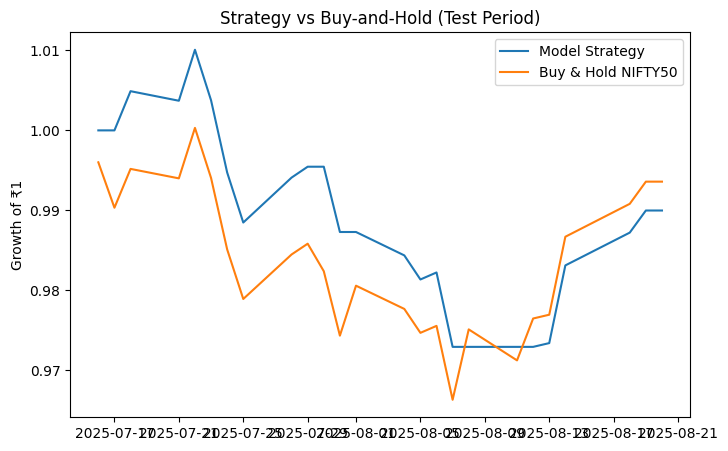

In [43]:
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = best_rf.predict(X_test)

# Strategy: go long only on days predicted 'Up' (1), otherwise stay in cash
test_df['next_day_return_pct'] = (test_df['close'].shift(-1) - test_df['close']) / test_df['close'] * 100
test_df['strategy_return'] = np.where(test_df['pred'] == 1, test_df['next_day_return_pct'], 0)

test_df['cumulative_strategy'] = (1 + test_df['strategy_return'].fillna(0)/100).cumprod()
test_df['cumulative_market'] = (1 + test_df['next_day_return_pct'].fillna(0)/100).cumprod()

plt.figure(figsize=(8,5))
plt.plot(test_df['date'], test_df['cumulative_strategy'], label='Model Strategy')
plt.plot(test_df['date'], test_df['cumulative_market'], label='Buy & Hold NIFTY50')
plt.legend(); plt.title('Strategy vs Buy-and-Hold (Test Period)')
plt.ylabel('Growth of ₹1'); plt.show()

⚠️ This backtest ignores transaction costs, slippage, and taxes, and uses a small test window — it is an **illustrative exercise, not a trading signal**. Say this explicitly in your written summary. Presenting it as a viable strategy without this caveat is the single most common mistake in student finance-ML projects.

### 7. Feature Importance

### Cell B11 — What Actually Mattered

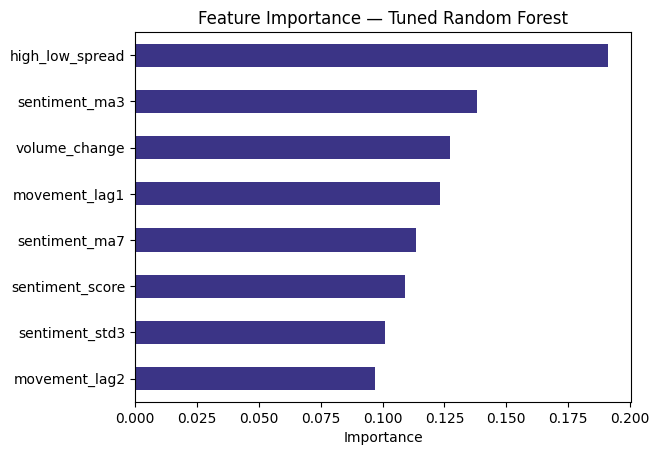

high_low_spread    0.190959
sentiment_ma3      0.138141
volume_change      0.127184
movement_lag1      0.123165
sentiment_ma7      0.113368
sentiment_score    0.109217
sentiment_std3     0.101128
movement_lag2      0.096838
dtype: float64


In [44]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', color='#3B3486')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.show()

print(importances.sort_values(ascending=False))

Discuss in your write-up: did the sentiment features (`sentiment_score`, `sentiment_ma3`, `sentiment_ma7`) rank above or below the pure price-history features (`movement_lag1`, `movement_lag2`, `volume_change`)? This is the single most interesting empirical result of the whole project — it directly answers the original problem statement with evidence, not assumption.

---
## Summary Numbers to Report

Run this cell last to pull together everything you need for your 1-page written summary.

In [45]:
print("="*50)
print("SUMMARY FOR WRITTEN REPORT")
print("="*50)
print(f"Part A same-day accuracy: {round(accuracy*100,2)}%  (baseline: {round(baseline_accuracy*100,2)}%)")
print(f"Part B majority baseline (next-day, test period): {round(majority_baseline*100,2)}%")
print(f"Part B Logistic Regression accuracy: {round(accuracy_score(y_test, y_pred_lr)*100,2)}%")
print(f"Part B Random Forest accuracy: {round(accuracy_score(y_test, y_pred_rf)*100,2)}%")
print(f"Part B Tuned RF accuracy: {round(accuracy_score(y_test, best_rf.predict(X_test))*100,2)}%")
print(f"Top feature: {importances.sort_values(ascending=False).index[0]}")

SUMMARY FOR WRITTEN REPORT
Part A same-day accuracy: 56.82%  (baseline: 50.76%)
Part B majority baseline (next-day, test period): 56.0%
Part B Logistic Regression accuracy: 56.0%
Part B Random Forest accuracy: 48.0%
Part B Tuned RF accuracy: 44.0%
Top feature: high_low_spread


### 8. Optional Stretch Goals

- Join the list of headlines into plain text before scoring (`' '.join(text)`) and check whether sentiment scores or model accuracy change noticeably.
- Swap the rule-based sentiment score for VADER or TextBlob and compare against the hand-built version from Part A.
- Add sector-level news (IT, banking, auto) and test whether sector-specific sentiment predicts sector indices better than Nifty overall.
- Try an LSTM or a simple Transformer classifier on the raw headline text instead of a hand-crafted sentiment score.
- Fork the GitHub repo, add your Part B notebook alongside the original, and open a pull request back to the Project Wing.

---
### Submission Checklist
- [ ] Notebook run top to bottom, all outputs visible
- [ ] 1-page written summary: key EDA finding, Part A accuracy vs. baseline, best Part B model + accuracy vs. baseline, one paragraph on what you'd do differently
- [ ] (Optional) Link to your fork/PR
